In [69]:
# Импортитируем необходимые библиотеки

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [38]:
# Смотрим на данные

housing = fetch_california_housing()
print(housing.data.shape, housing.target.shape)
print(housing.feature_names[0:6])

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


20640 строк

8 колонок

In [39]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["target"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


* MedInc (Median Income): Медианный доход семей в этом микрорайоне (измеряется в десятках тысяч долларов, например, 8.32 означает примерно $83,200 в год).
  
* HouseAge (Housing Median Age): Медианный возраст домов в районе (сколько лет зданиям).
  
* AveRooms (Average Rooms): Среднее количество комнат в жилом доме/квартире этого района.
  
* AveBedrms (Average Bedrooms): Среднее количество спален в жилье.
  
* Population: Общее количество жителей, проживающих в данном микрорайоне.
  
* AveOccup (Average Occupancy): Среднее число жильцов в одном доме (рассчитывается как общее население, деленное на число домохозяйств).
  
* Latitude: Географическая широта расположения района.
  
* Longitude: Географическая долгота расположения района.
  
* target: Медианная стоимость дома в этом районе. Именно её мы и пытаемся предсказать (измеряется в сотнях тысяч долларов, например, 4.526 означает $452,600).


In [40]:
# Проверяем есть ли пропуски в данных

df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

Пропусков нет

In [41]:
# Очистка от аномалий: оставляем данные между 0.1% и 99.9% перцентилями

columns_to_clean = ["AveRooms", "AveBedrms", "Population", "AveOccup"]
for col in columns_to_clean:
    lower_bound = df[col].quantile(0.001)
    upper_bound = df[col].quantile(0.999)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Размер данных после чистки аномалий: {df.shape}")

Размер данных после чистки аномалий: (20473, 9)


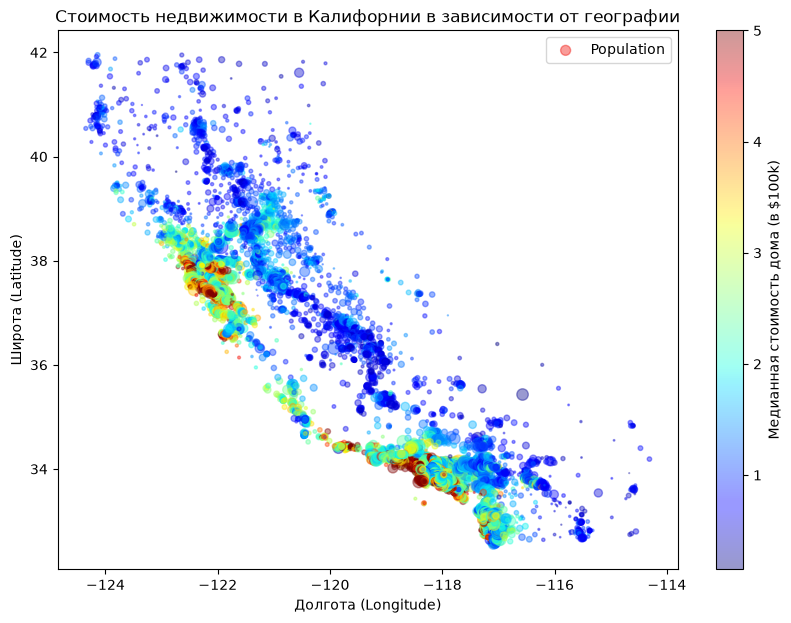

In [42]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["target"],
    s=df["Population"] / 100,
    alpha=0.4,
    cmap="jet",
    label="Population",
)
plt.colorbar(sc, label="Медианная стоимость дома (в $100k)")
plt.xlabel("Долгота (Longitude)")
plt.ylabel("Широта (Latitude)")
plt.title("Стоимость недвижимости в Калифорнии в зависимости от географии")
plt.legend()
plt.show()

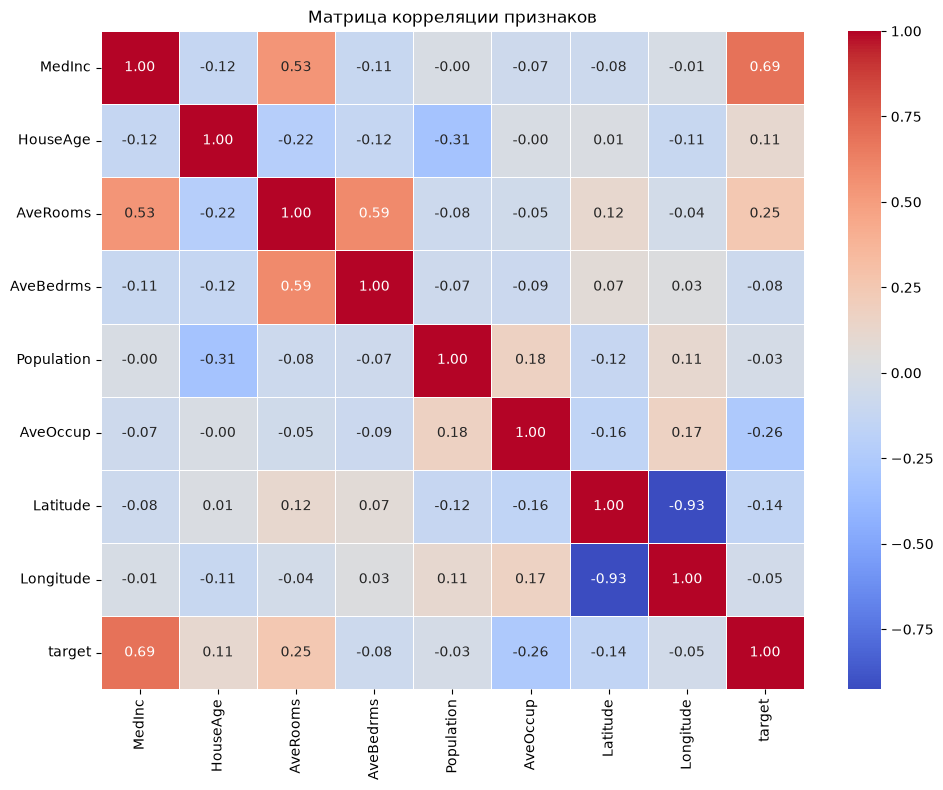

Корреляция признаков с целевой переменной (target):
target        1.000000
MedInc        0.690852
AveRooms      0.248992
HouseAge      0.106426
Population   -0.028925
Longitude    -0.045764
AveBedrms    -0.079709
Latitude     -0.144592
AveOccup     -0.261145
Name: target, dtype: float64


In [43]:
# 1. Считаем матрицу корреляции для всего датафрейма
corr_matrix = df.corr()

# 2. Настраиваем размер графика
plt.figure(figsize=(10, 8))

# 3. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,  # показывать коэффициенты внутри ячеек
    cmap="coolwarm",  # синий — отрицательная, красный — положительная корреляция
    fmt=".2f",  # округление до двух знаков после запятой
    linewidths=0.5,  # сетка между ячейками
)

plt.title("Матрица корреляции признаков")
plt.tight_layout()
plt.show()

# 4. Выведем корреляцию конкретно с целевой переменной (отсортированную по убыванию)
print("Корреляция признаков с целевой переменной (target):")
print(corr_matrix["target"].sort_values(ascending=False))

In [44]:
X = df.drop(columns=['target'])
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

In [45]:
def grade_model(grade):
    print(f'Train {grade.__name__}: {grade(y_train, y_train_pred):.4f}')
    print(f'Test {grade.__name__}: {grade(y_test, y_test_pred):.4f}')
    print('-'*25)

In [46]:
grade_model(mean_squared_error)
grade_model(mean_absolute_error)
grade_model(r2_score)

Train mean_squared_error: 0.4549
Test mean_squared_error: 0.4527
-------------------------
Train mean_absolute_error: 0.4907
Test mean_absolute_error: 0.4949
-------------------------
Train r2_score: 0.6555
Test r2_score: 0.6658
-------------------------


Модель умеренно объясняет данные (R² ≈ 0.66), с небольшой средней ошибкой (~0.5), и хорошо обобщается на новые данные

In [52]:
weights = pd.Series(lr.coef_, index=X.columns)
top_features = weights.abs().sort_values(ascending=False)
print(weights[top_features.index].head(10))

AveBedrms     0.857257
MedInc        0.433190
Latitude     -0.429034
Longitude    -0.424615
AveOccup     -0.304060
AveRooms     -0.110081
HouseAge      0.010405
Population    0.000037
dtype: float64


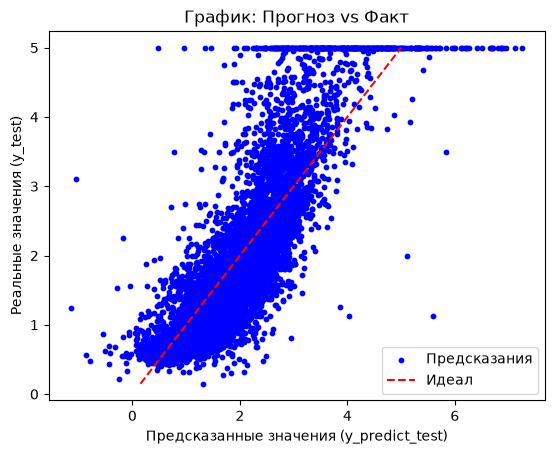

In [56]:
# 1. Строим точки (сравнение предсказанных y и реальных y)
plt.scatter(y_test_pred, y_test, s=10, c='b', label='Предсказания')

# 2. Добавляем идеальную прямую линию (где предсказание строго равно факту)
# Если все точки лежат на этой линии — модель идеальна
all_y = y_test
plt.plot([all_y.min(), all_y.max()], [all_y.min(), all_y.max()], c='r', linestyle='--', label='Идеал')

# 3. Подписываем оси и добавляем легенду
plt.xlabel('Предсказанные значения (y_predict_test)')
plt.ylabel('Реальные значения (y_test)')
plt.title('График: Прогноз vs Факт')
plt.legend()

# 4. Показываем график
plt.show()


In [70]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

model = LassoCV(cv=5)
model.fit(X_train, y_train)

print(model.alpha_)


0.0007921763823333984


In [71]:
# 2. создаём модель Lasso
lasso = Lasso(alpha=0.0007921763823333984)
lasso.fit(x_train, y_train)
y_train_pred = lasso.predict(x_train)
y_test_pred = lasso.predict(x_test)

In [72]:
grade_model(mean_squared_error)
grade_model(mean_absolute_error)
grade_model(r2_score)

Train mean_squared_error: 0.4550
Test mean_squared_error: 0.4526
-------------------------
Train mean_absolute_error: 0.4909
Test mean_absolute_error: 0.4950
-------------------------
Train r2_score: 0.6554
Test r2_score: 0.6659
-------------------------
